In [1]:
# importing packages
import numpy as np
from matplotlib import pyplot as plt
import math
import scipy.stats as stats
import pandas as pd

# Linear regression of the probe cell constant

In [2]:
# extracting data
data = pd.read_csv(".\Data\Probe_calibration.csv")
current = data["I"]
voltage = data["V"]
cond = data["Cond"]

# number of data points
n_data = len(cond)

In [3]:
# input variables
current_divide_voltage = [current[i]/voltage[i] for i in range(n_data)]

# Matrix of input variables
X = np.zeros((n_data, 1))
X[:, 0] = current_divide_voltage

In [4]:
# X transpose multiply X
A = np.matmul(np.transpose(X), X)

# A inverse
A_inv = np.linalg.inv(A)
print(A_inv)

[[1469.67848702]]


In [5]:
# X transpose multiply conductivity
B = np.matmul(np.transpose(X), cond)

# calculate the parameter estimate in micro/cm
beta_hat = np.matmul(A_inv, B)
print(f"Beta hat is:{beta_hat}")

Beta hat is:[496745.24060041]


In [6]:
# get the cell constant
cell_constant = beta_hat*10**(-6) #cm^(-1)
print(f"The cell constant is: {cell_constant}")

The cell constant is: [0.49674524]


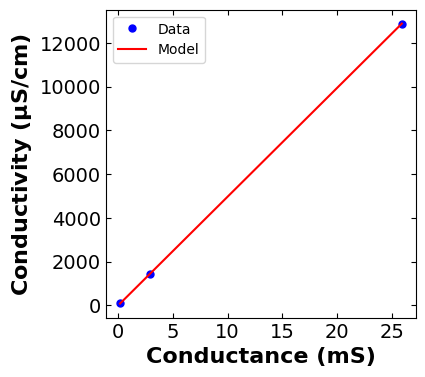

In [7]:
# evaluating model predictions
cond_pred = np.matmul(beta_hat, np.transpose(X))

# conductance in mS
current_divide_voltage_plot = [current_divide_voltage[i] * 1000 for i in range(n_data)]

# plot comparing the predictions with the data
fig = plt.figure(figsize=(4,4))
plt.plot(current_divide_voltage_plot, cond, "b.", markersize=10, label="Data")
plt.plot(current_divide_voltage_plot, cond_pred, "r-", label="Model")
plt.xlabel("Conductance (mS)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity ($\mathbf{\mu}$S/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend()
plt.show()

Percent prediction residuals are: [-5.15422908305469, 0.9244792410344264, -0.011022423428056986]


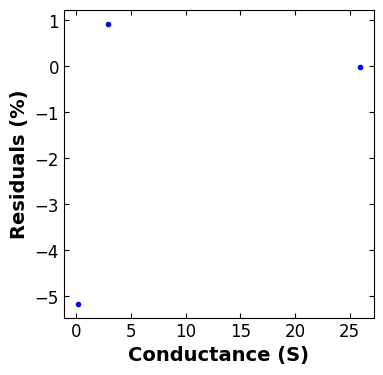

In [8]:
# calculate the prediction residuals
e = [cond_pred[i] - cond[i] for i in range(n_data)]

# percent prediction residuals
percent_residuals = [(e[i]/cond[i])*100 for i in range(n_data)]
print(f"Percent prediction residuals are: {percent_residuals}")

# plot the percent prediction residuals
fig = plt.figure(figsize=(4,4))
plt.plot(current_divide_voltage_plot, percent_residuals, "b.")
plt.xlabel("Conductance (S)", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in",top=True, right=True)
plt.show()

In [9]:
# sum of squared errors
sse = sum(e[i]**2 for i in range(n_data))

# variance of the measurement error
sigma_meas = sse/(n_data - 1)
standard_dev = math.sqrt(sigma_meas)
print(f"Variance of the measurement error is: {sigma_meas}")
print(f"Standard deviation of the measurement error is: {standard_dev}")

Variance of the measurement error is: 95.69983879203038
Standard deviation of the measurement error is: 9.782629441618974


## R-squared calculation

In [10]:
# mean value of the conductivity measurements
cond_mean = np.mean(cond)

# deviation of the conductivity measurements from the mean value
cond_dev = [cond[i] - cond_mean for i in range(n_data)]

# sum of squared errors for the deviation between the conductivity measurements and the mean value
cond_dev_sse = sum(cond_dev[i]**2 for i in range(n_data))

# r-squared
r_squared = 1 - (sse/cond_dev_sse)
print(f"r-squared of the fit is: {r_squared}")

r-squared of the fit is: 0.9999980666435334


# Error propagation